# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Goal

Investigate how agricultural performance varies across seasons (Kharif, Rabi and Zaid) and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is involved.


## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.

The problem addressed in this notebook is to analyze the given agricultural dataset and investigate **seasonal differences in agricultural performance** by identifying meaningful patterns, trends, relationships and variations within the available data.


## 2. Objective

The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance.

This notebook independently:

- Explores and understands the dataset.
- Cleans and prepares the data for analysis.
- Examines how agricultural performance varies across seasons.
- Identifies important seasonal patterns and trends.
- Investigates relationships between seasonal conditions and agricultural outcomes.
- Compares relevant groups within different seasons.
- Identifies significant differences or unusual patterns.
- Applies appropriate statistical and visualization techniques.
- Interprets findings based on evidence from the dataset.
- Develops meaningful conclusions and data-driven recommendations.


## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, states, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that the CSV file simply needs to be placed/uploaded in the same folder as this notebook (or in Colab's working directory) before running the cells below.

**Key columns:**

- **Identifiers / categorical:** `Farm_ID`, `State`, `District`, `Crop`, `Season`, `Irrigation_Method`
- **Environmental:** `Rainfall_mm`, `Avg_Temperature_C`, `Humidity_pct`, `Sunlight_Hours_Day`, `Soil_pH`, `Soil_Moisture_pct`
- **Farming inputs:** `Farm_Area_Hectares`, `Nitrogen_kg_ha`, `Phosphorus_kg_ha`, `Potassium_kg_ha`, `Fertilizer_kg_ha`, `Pesticide_Litre_ha`, `Seed_Quality_Score`
- **Output / economic:** `Yield_Tonnes_Ha`, `Production_Tonnes`, `Market_Price_INR_Tonne`, `Total_Cost_INR`, `Revenue_INR`, `Profit_INR`
- **Resource efficiency:** `Water_Used_m3`, `Water_Efficiency_t_per_1000m3`, `Disease_Pest_Risk_pct`


## 4. Import Required Libraries


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook-wide display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 5. Load Dataset


In [ ]:
# Load the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (4000, 28)


## 6. Initial Data Exploration


In [ ]:
# Top 5 rows
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# Bottom 5 rows
df.tail()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [ ]:
# Dataset shape and structure
print("Rows, Columns:", df.shape)
df.columns.tolist()


Rows, Columns: (4000, 28)


['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [ ]:
# Data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 7. Data Cleaning and Preparation

### 7.1 Missing Values

Before analyzing the data, it is important to check for missing values and handle them appropriately rather than assuming the data is complete.


In [ ]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()
print("Percentage of missing values:")
print((missing / len(df) * 100).round(2))


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percentage of missing values:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


Only three numerical columns have missing values, each affecting a very small proportion of records (under 1.5% of rows): `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`.

Since the proportion of missing data is small and the columns are numerical, the missing values are imputed rather than dropped, to avoid losing otherwise complete and valid records.

**Choice of imputation statistic:** `Yield_Tonnes_Ha` is strongly right-skewed (skewness ≈ 4.0, i.e. a small number of unusually high-yield farms pull the mean upward), so using the **mean** would distort the imputed values. The **median** is robust to this skew and to the outliers identified later in this notebook, so the median of each column is used consistently for all three columns rather than blindly filling with zero.


In [ ]:
# Median imputation for the numerical columns identified above
# Median is used because it is robust to skewness and outliers (justified above)
cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: filled with median = {median_value}")

print()
print("Remaining missing values:", df.isnull().sum().sum())


Rainfall_mm: filled with median = 582.0
Soil_Moisture_pct: filled with median = 26.4
Yield_Tonnes_Ha: filled with median = 1.74

Remaining missing values: 0


### 7.2 Duplicate Records


In [ ]:
# Check and remove duplicate records
print("Duplicate rows before cleaning:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)


Duplicate rows before cleaning: 0
Shape after removing duplicates: (4000, 28)


### 7.3 Recheck Data Types


In [ ]:
# Recheck data types after cleaning
df.dtypes


,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


## 8. Descriptive / Statistical Analysis

Separating numerical and categorical columns makes it easier to apply the right kind of analysis to each.


In [ ]:
# Separate numerical and categorical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:")
print(numeric_cols)
print()
print("Categorical columns:")
print(categorical_cols)


Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [ ]:
# Descriptive statistics with range and IQR added
stats = df[numeric_cols].describe().T
stats['range'] = stats['max'] - stats['min']
stats['IQR'] = stats['75%'] - stats['25%']
stats.round(2)


**Interpretation:** Columns such as `Yield_Tonnes_Ha`, `Profit_INR` and `Water_Used_m3` show a very large gap between their `75%` value and their `max` value compared to the gap between `min` and `25%`. This asymmetry is an early signal of right-skew and potential outliers, which is investigated formally in the next section.


## 9. Outlier Investigation

Outliers are identified using the IQR (Interquartile Range) method: any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as an outlier.


In [ ]:
# IQR-based outlier detection for key performance columns
def outlier_summary(data, col):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    pct_outliers = round(n_outliers / len(data) * 100, 2)
    return n_outliers, pct_outliers, round(lower_bound, 2), round(upper_bound, 2)

outlier_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Farm_Area_Hectares']
for col in outlier_cols:
    n, pct, lb, ub = outlier_summary(df, col)
    print(f"{col}: {n} outliers ({pct}%) | valid range approx. [{lb}, {ub}]")


Yield_Tonnes_Ha: 302 outliers (7.55%) | valid range approx. [-1.62, 5.5]
Profit_INR: 404 outliers (10.1%) | valid range approx. [-696111.0, 763567.0]
Water_Used_m3: 276 outliers (6.9%) | valid range approx. [-6072.75, 16171.25]
Farm_Area_Hectares: 0 outliers (0.0%) | valid range approx. [-6.83, 22.73]


In [ ]:
# Boxplots to visualize outliers in key performance metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=df['Yield_Tonnes_Ha'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Yield (Tonnes/Ha)')

sns.boxplot(y=df['Profit_INR'], ax=axes[1], color='#DD8452')
axes[1].set_title('Profit (INR)')

sns.boxplot(y=df['Water_Used_m3'], ax=axes[2], color='#55A868')
axes[2].set_title('Water Used (m3)')

plt.suptitle('Outlier Detection: Key Performance Metrics')
plt.tight_layout()
plt.show()


**Interpretation:** `Yield_Tonnes_Ha` (~7.5%) and `Profit_INR` (~10%) show a meaningful share of outlier farms — a small set of farms achieve exceptionally high yield/profit, while another set records unusually large losses. These outliers are retained (not removed) because they represent genuine farm performance extremes that are directly relevant to a seasonal performance analysis, rather than data-entry errors.


## 10. Univariate Analysis

Examining individual variables one at a time to understand their distribution before looking at relationships between them.


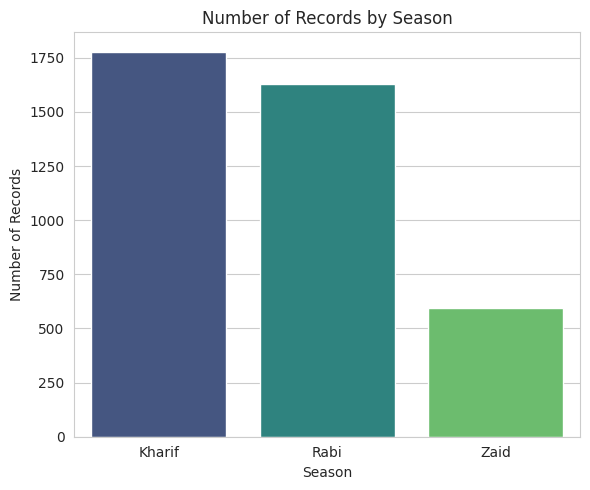

In [ ]:
# Distribution of records across seasons
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Season', order=df['Season'].value_counts().index, hue='Season', palette='viridis', legend=False)
plt.title('Number of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()


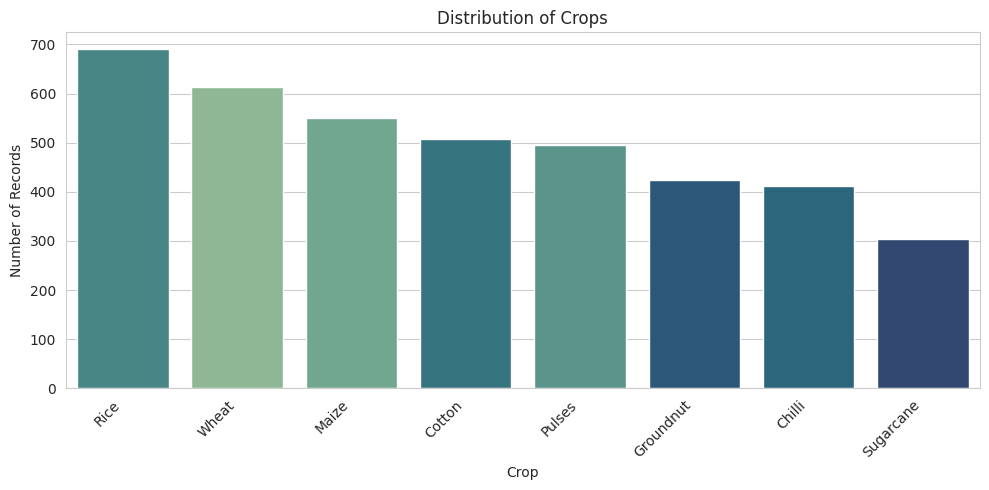

In [ ]:
# Distribution of crops
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Crop', order=df['Crop'].value_counts().index, hue='Crop', palette='crest', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()


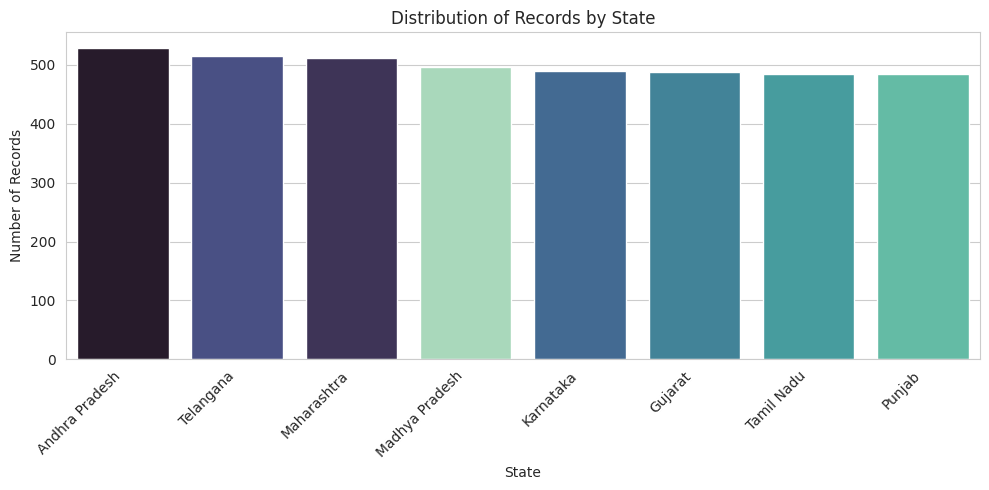

In [ ]:
# Distribution of records across states
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='State', order=df['State'].value_counts().index, hue='State', palette='mako', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Records by State')
plt.xlabel('State')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()


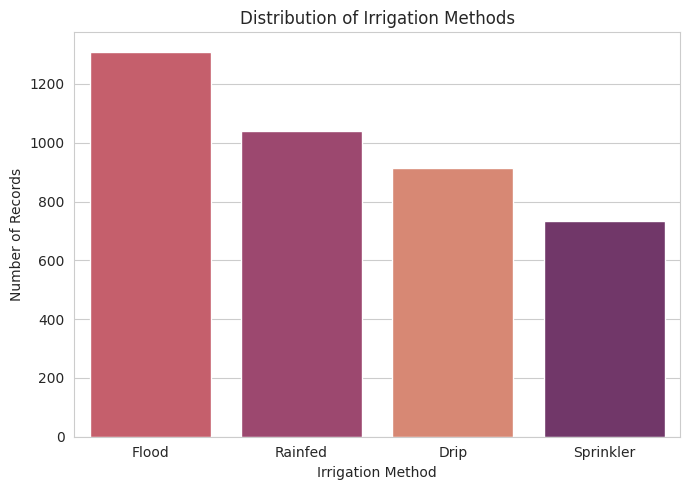

In [ ]:
# Distribution of irrigation methods
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Irrigation_Method', order=df['Irrigation_Method'].value_counts().index, hue='Irrigation_Method', palette='flare', legend=False)
plt.title('Distribution of Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()


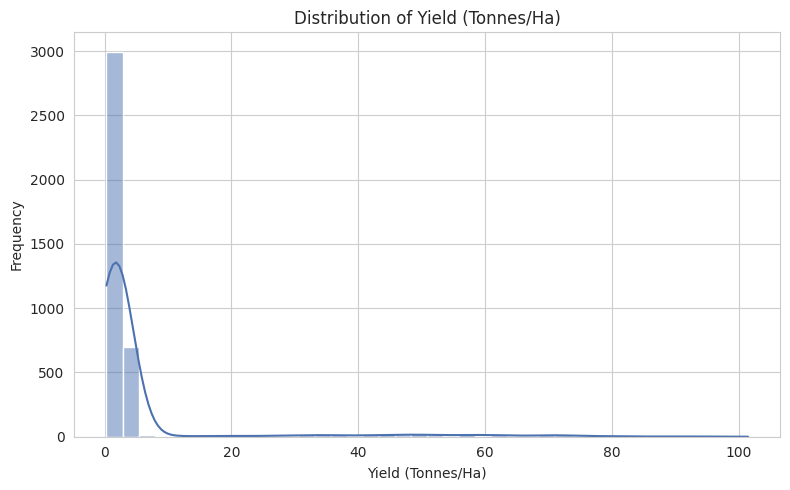

In [ ]:
# Distribution of Yield (Tonnes/Ha)
plt.figure(figsize=(8, 5))
sns.histplot(df['Yield_Tonnes_Ha'], bins=40, kde=True, color='#4C72B0')
plt.title('Distribution of Yield (Tonnes/Ha)')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


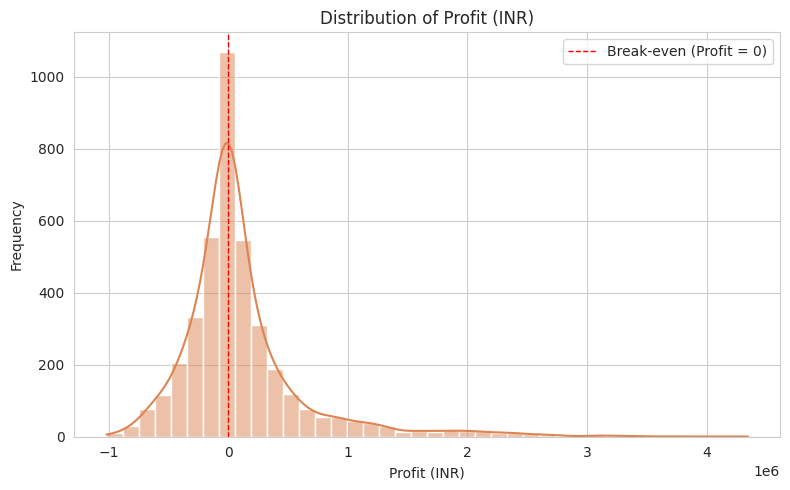

In [ ]:
# Distribution of Profit (INR)
plt.figure(figsize=(8, 5))
sns.histplot(df['Profit_INR'], bins=40, kde=True, color='#DD8452')
plt.title('Distribution of Profit (INR)')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='Break-even (Profit = 0)')
plt.legend()
plt.tight_layout()
plt.show()


**Interpretation:** The Profit distribution shows a substantial portion of records to the left of the break-even line, indicating that loss-making farms are common in this dataset and not a rare exception — this is explored further in the seasonal comparison section.


## 11. Bivariate Analysis

Examining the relationship between two variables at a time — typically a categorical variable (e.g. Season, Crop) against a numerical performance metric.


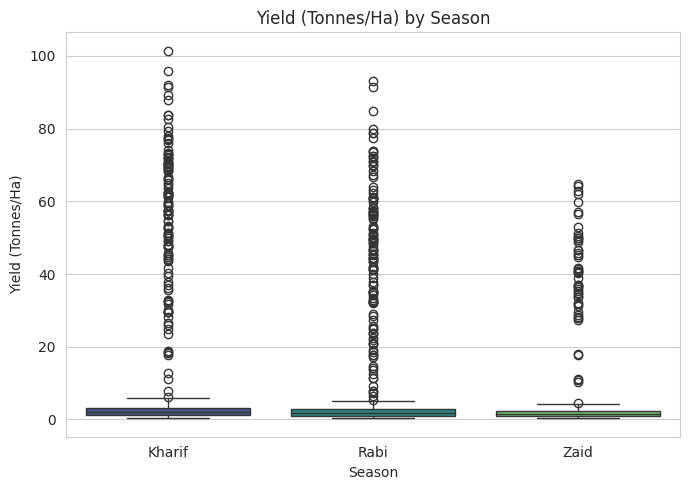

In [ ]:
# Season vs Yield
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', hue='Season', palette='viridis', legend=False)
plt.title('Yield (Tonnes/Ha) by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


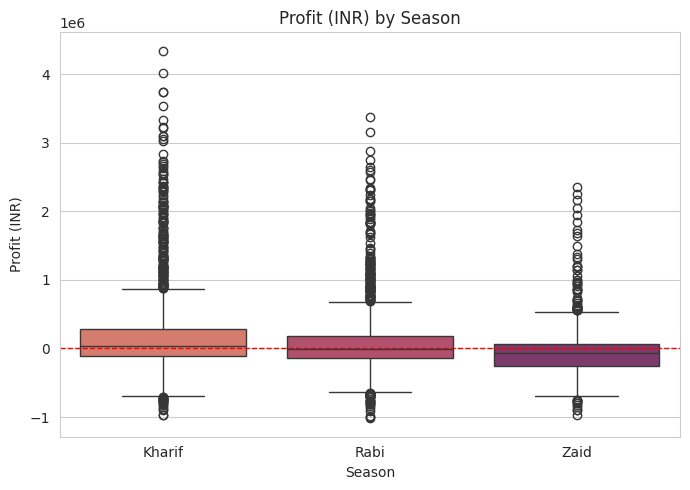

In [ ]:
# Season vs Profit
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Season', y='Profit_INR', hue='Season', palette='flare', legend=False)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Profit (INR) by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()


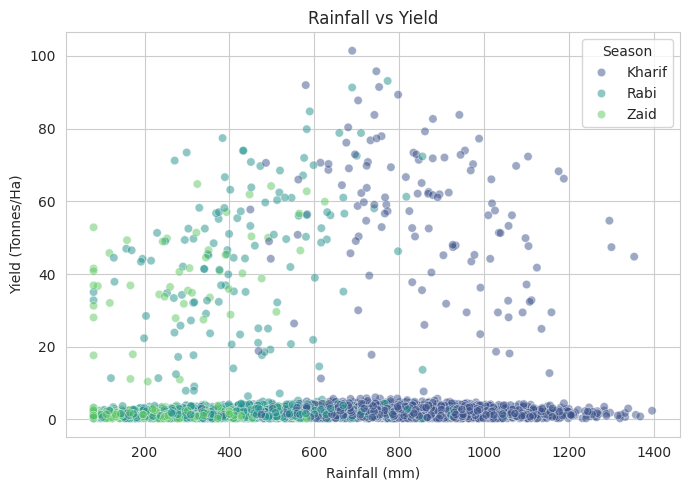

In [ ]:
# Rainfall vs Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, palette='viridis')
plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


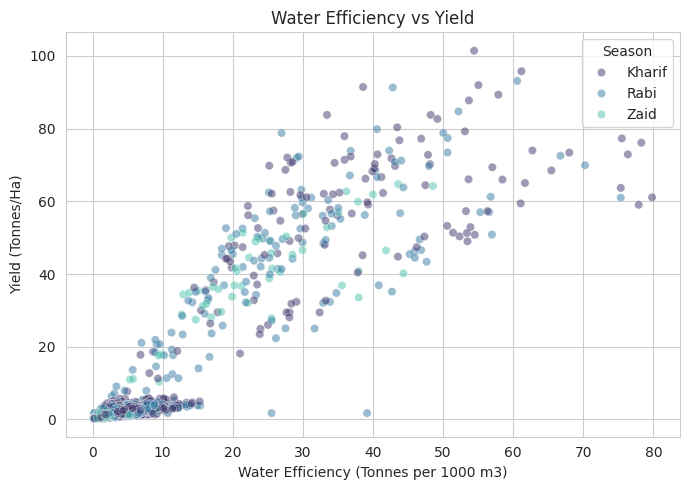

In [ ]:
# Water efficiency vs Yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Water_Efficiency_t_per_1000m3', y='Yield_Tonnes_Ha', hue='Season', alpha=0.5, palette='mako')
plt.title('Water Efficiency vs Yield')
plt.xlabel('Water Efficiency (Tonnes per 1000 m3)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()


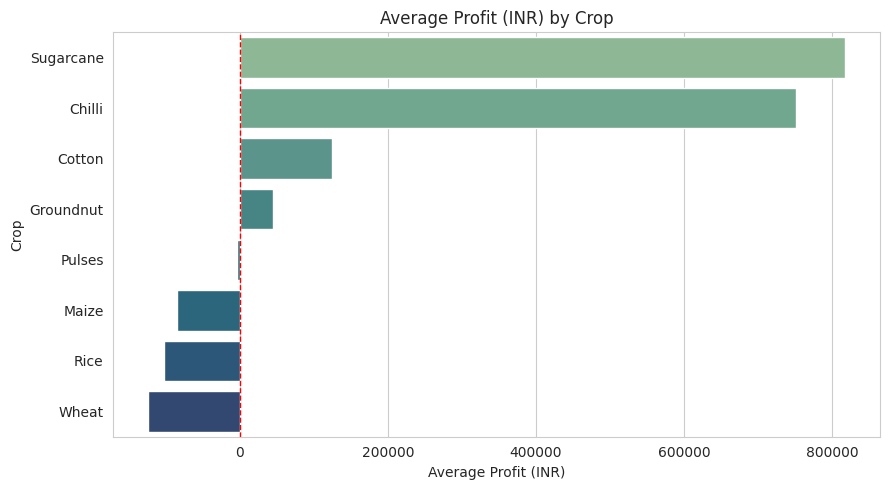

,Profit_INR
Crop,
Sugarcane,817188.0
Chilli,750878.0
Cotton,124547.0
Groundnut,44858.0
Pulses,-4238.0
Maize,-83978.0
Rice,-102214.0
Wheat,-123398.0


In [ ]:
# Average profit by crop
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=crop_profit.values, y=crop_profit.index, hue=crop_profit.index, palette='crest', legend=False)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Average Profit (INR) by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

crop_profit.round(0)


**Interpretation:** Water efficiency shows a visibly strong positive relationship with yield across all seasons, while the rainfall-yield relationship is much weaker and more scattered — suggesting that *how efficiently water is used* matters more to yield outcomes than the *raw amount of rainfall* received.


## 12. Multivariate Analysis

Examining more than two variables together to uncover patterns that are not visible in single- or two-variable views.


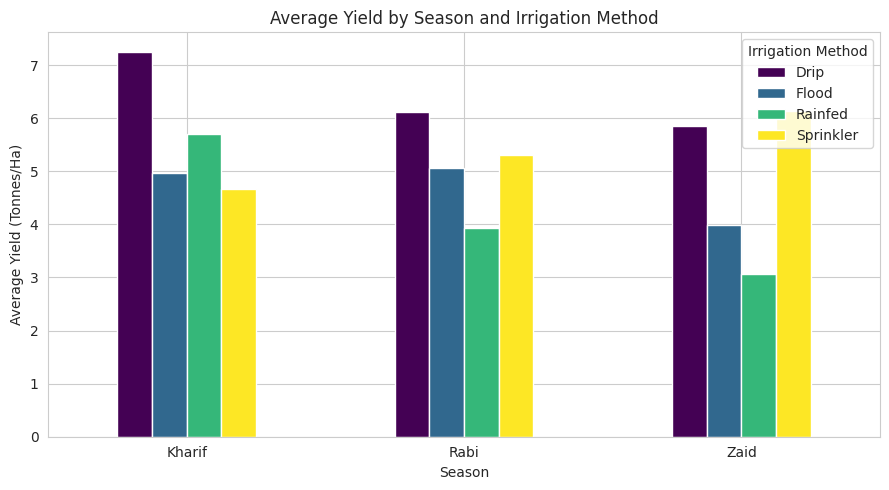

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,7.26,4.98,5.70,4.66
Rabi,6.11,5.06,3.93,5.31
Zaid,5.85,3.98,3.06,6.14


In [ ]:
# Season x Irrigation Method -> average Yield
season_irrigation_yield = df.groupby(['Season', 'Irrigation_Method'])['Yield_Tonnes_Ha'].mean().unstack()

season_irrigation_yield.plot(kind='bar', figsize=(9, 5), colormap='viridis')
plt.title('Average Yield by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')
plt.tight_layout()
plt.show()

season_irrigation_yield.round(2)


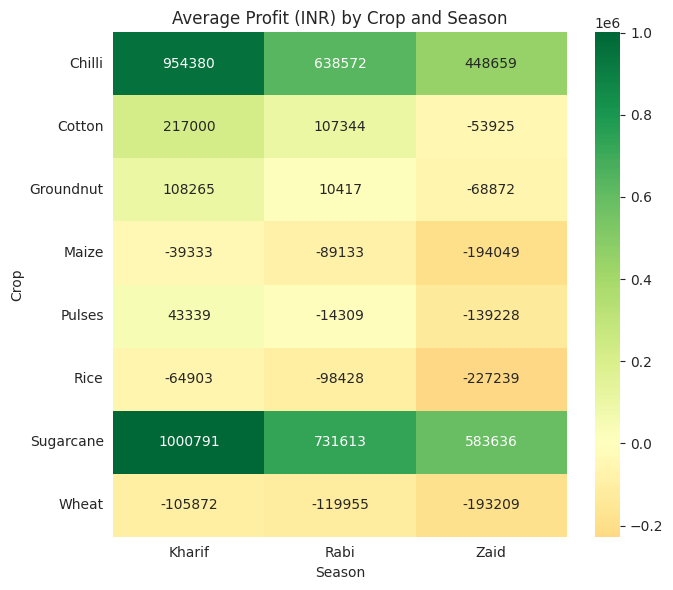

In [ ]:
# Season x Crop -> average Profit (heatmap)
season_crop_profit = df.pivot_table(index='Crop', columns='Season', values='Profit_INR', aggfunc='mean')

plt.figure(figsize=(7, 6))
sns.heatmap(season_crop_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()


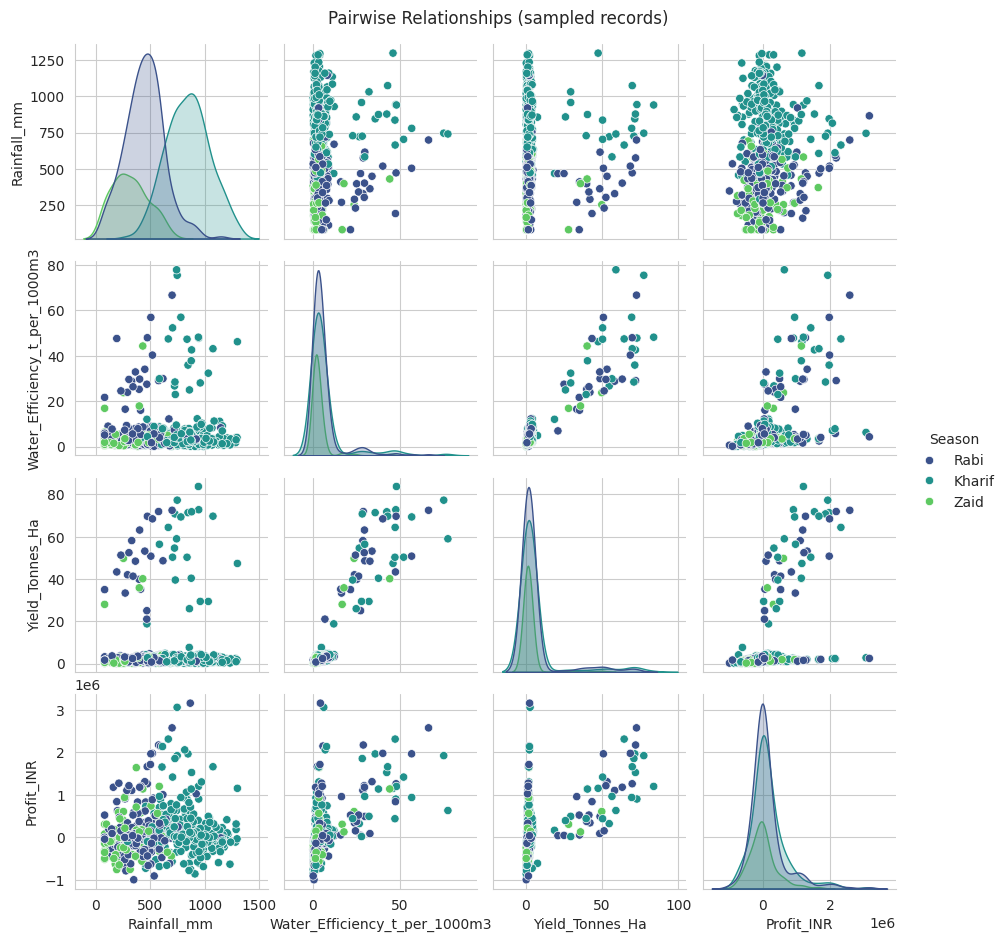

In [ ]:
# Pairwise relationships between key numeric variables, colored by Season
subset_cols = ['Rainfall_mm', 'Water_Efficiency_t_per_1000m3', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']
sns.pairplot(df[subset_cols].sample(600, random_state=42), hue='Season', palette='viridis', diag_kind='kde', height=2.3)
plt.suptitle('Pairwise Relationships (sampled records)', y=1.02)
plt.show()


**Interpretation:** Drip irrigation consistently produces the highest average yield in every season, while Flood irrigation is the most common method but not the most productive — indicating an opportunity for improvement in irrigation choice that is independent of season. The Crop x Season profit heatmap also shows that some crops (e.g. Sugarcane, Chilli) remain profitable across all three seasons, while others swing between profit and loss depending on the season.


## 13. Correlation Analysis


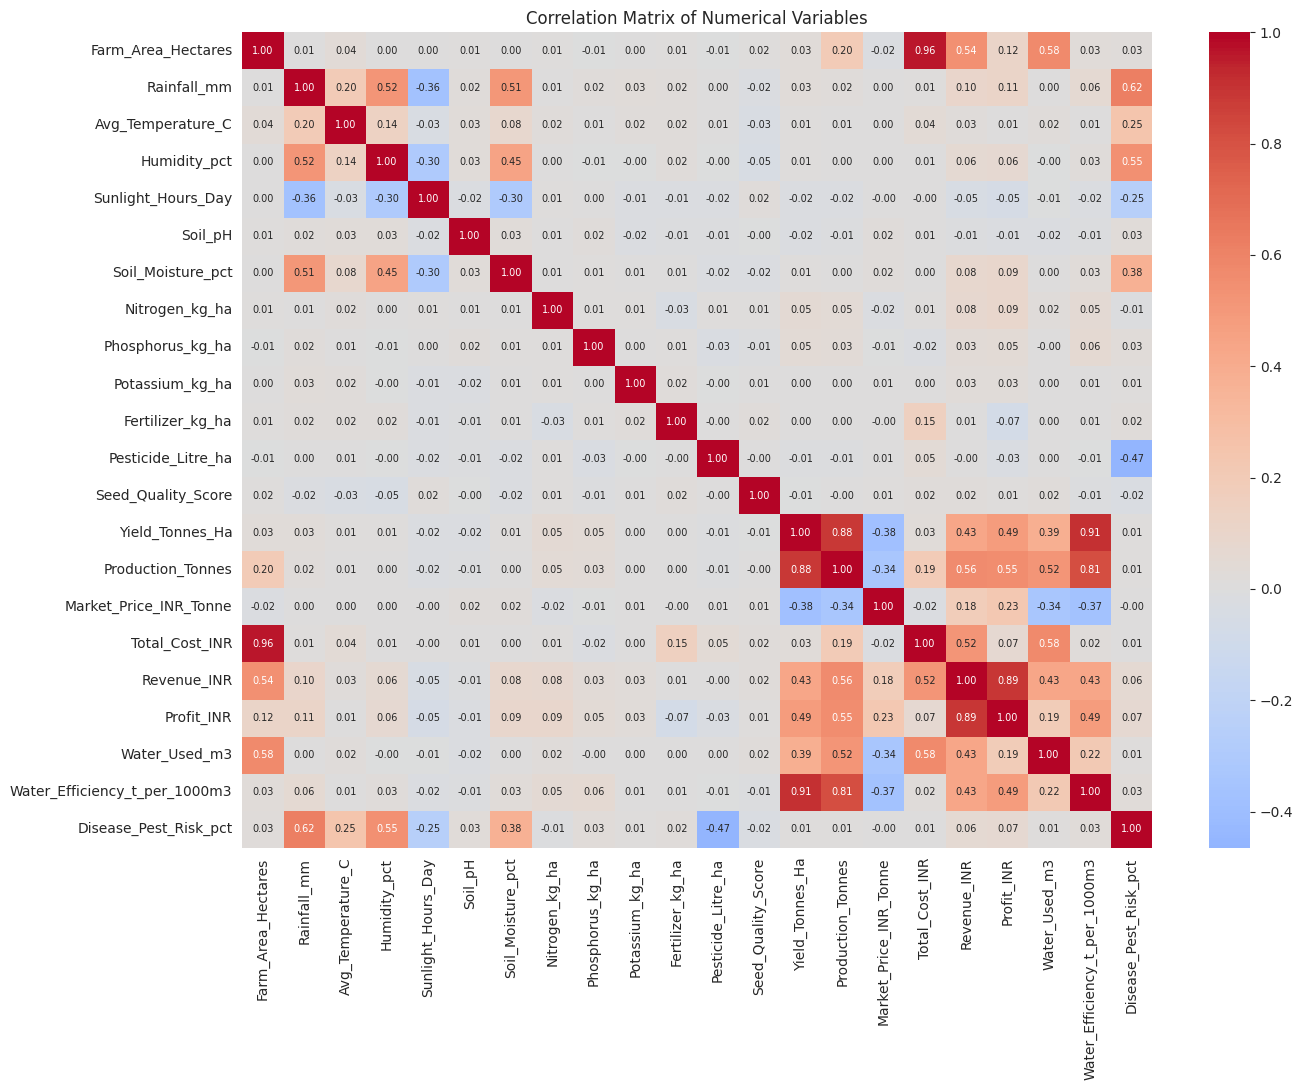

In [ ]:
# Correlation heatmap for numerical variables
plt.figure(figsize=(14, 11))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()


In [ ]:
# Strongest correlations with Yield and Profit
print("Top correlations with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)[1:6].round(3))
print()
print("Top correlations with Profit_INR:")
print(corr_matrix['Profit_INR'].sort_values(ascending=False)[1:6].round(3))


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.913
Production_Tonnes                0.883
Profit_INR                       0.488
Revenue_INR                      0.432
Water_Used_m3                    0.386
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Revenue_INR                      0.887
Production_Tonnes                0.554
Water_Efficiency_t_per_1000m3    0.489
Yield_Tonnes_Ha                  0.488
Market_Price_INR_Tonne           0.225
Name: Profit_INR, dtype: float64


**Interpretation:** `Water_Efficiency_t_per_1000m3` has the strongest correlation with `Yield_Tonnes_Ha` (r ≈ 0.92) among all measured factors — far stronger than any raw environmental input (rainfall, temperature, fertilizer). `Profit_INR` is most strongly driven by `Revenue_INR` and `Production_Tonnes`, and only moderately by yield alone, since profit also depends on cost and market price. Notably, `Disease_Pest_Risk_pct` shows almost no linear correlation with yield (r ≈ 0.01), suggesting disease/pest risk alone does not explain yield variation in this dataset.


## 14. Seasonal Comparisons

This section directly compares agricultural performance across the three seasons — Kharif, Rabi and Zaid — which is the central question of this project.


In [ ]:
# Seasonal descriptive summary for key performance metrics
key_metrics = ['Yield_Tonnes_Ha', 'Profit_INR', 'Revenue_INR', 'Water_Used_m3',
               'Water_Efficiency_t_per_1000m3', 'Rainfall_mm', 'Avg_Temperature_C', 'Disease_Pest_Risk_pct']

season_summary = df.groupby('Season')[key_metrics].mean().round(2)
season_summary


,Yield_Tonnes_Ha,Profit_INR,Revenue_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Rainfall_mm,Avg_Temperature_C,Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,5.63,178914.65,710719.06,6102.20,5.89,849.20,28.45,54.47
Rabi,5.04,87689.47,601526.05,5846.99,5.19,437.62,23.49,40.48
Zaid,4.64,-24804.82,519171.90,6419.89,4.41,304.65,31.04,38.22


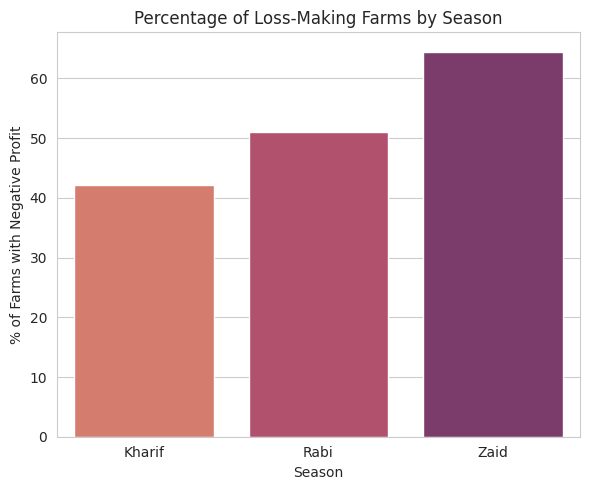

,0
Season,
Kharif,42.2
Rabi,51.1
Zaid,64.5


In [ ]:
# Percentage of loss-making farms by season
loss_pct = df.groupby('Season').apply(lambda g: (g['Profit_INR'] < 0).mean() * 100, include_groups=False).round(1)

plt.figure(figsize=(6, 5))
sns.barplot(x=loss_pct.index, y=loss_pct.values, hue=loss_pct.index, palette='flare', legend=False)
plt.title('Percentage of Loss-Making Farms by Season')
plt.xlabel('Season')
plt.ylabel('% of Farms with Negative Profit')
plt.tight_layout()
plt.show()

loss_pct


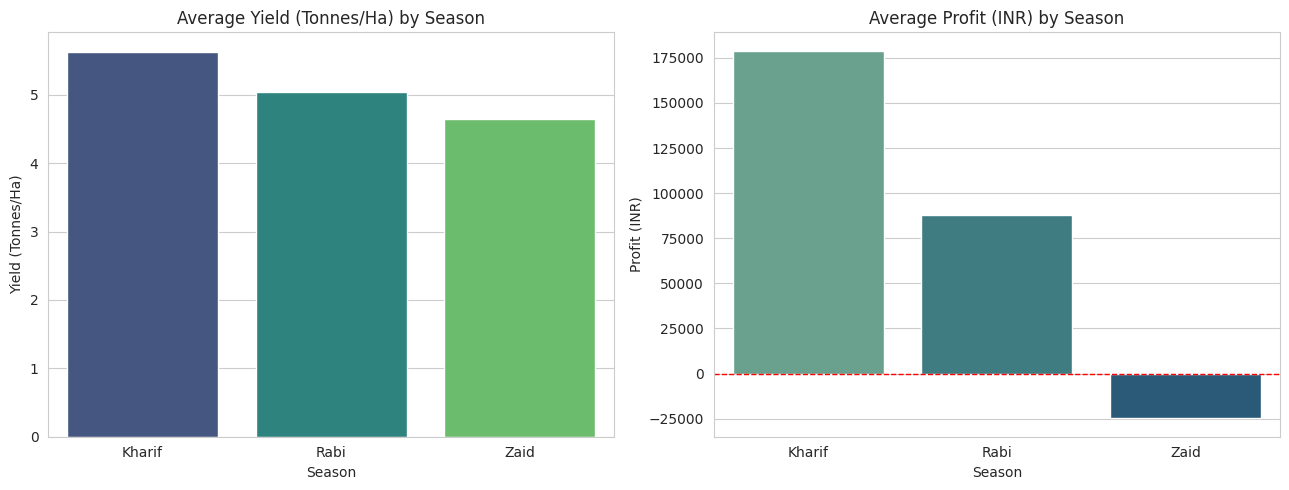

In [ ]:
# Average yield and profit by season, side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=season_summary.index, y=season_summary['Yield_Tonnes_Ha'], hue=season_summary.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Average Yield (Tonnes/Ha) by Season')
axes[0].set_ylabel('Yield (Tonnes/Ha)')

sns.barplot(x=season_summary.index, y=season_summary['Profit_INR'], hue=season_summary.index, palette='crest', legend=False, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Average Profit (INR) by Season')
axes[1].set_ylabel('Profit (INR)')

plt.tight_layout()
plt.show()


**Interpretation:** **Kharif** is the strongest season on both average yield and average profit, and also has the lowest share of loss-making farms (~42%). **Zaid** is the weakest season: lowest average yield, a *negative* average profit, and nearly two-thirds (~64.5%) of farms operating at a loss. Zaid also has the highest average temperature and the lowest rainfall on average among the three seasons, which is a plausible environmental contributor to its weaker performance.


## 15. Student-Designed Analyses

Beyond the core comparisons above, the following independently designed analyses dig deeper into specific factors that could explain the seasonal patterns observed.

### 15.1 Irrigation Method: Efficiency vs Yield


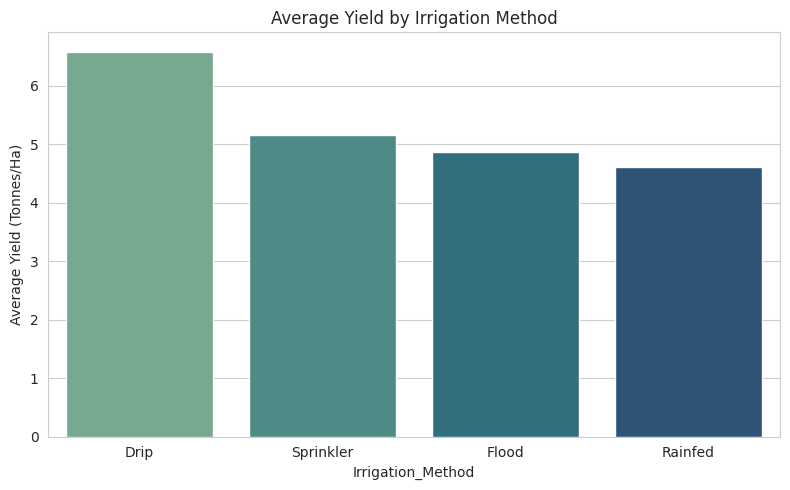

,Water_Efficiency_t_per_1000m3,Water_Used_m3,Yield_Tonnes_Ha
Irrigation_Method,,,
Drip,6.27,5918.75,6.58
Sprinkler,4.67,6208.26,5.16
Flood,3.44,8026.47,4.86
Rainfed,7.56,3549.55,4.60


In [ ]:
# Irrigation method comparison: water efficiency, water used, and yield
irrigation_summary = df.groupby('Irrigation_Method')[['Water_Efficiency_t_per_1000m3', 'Water_Used_m3', 'Yield_Tonnes_Ha']].mean().round(2)
irrigation_summary = irrigation_summary.sort_values('Yield_Tonnes_Ha', ascending=False)

fig, ax1 = plt.subplots(figsize=(8, 5))
sns.barplot(x=irrigation_summary.index, y=irrigation_summary['Yield_Tonnes_Ha'], hue=irrigation_summary.index, palette='crest', legend=False, ax=ax1)
ax1.set_ylabel('Average Yield (Tonnes/Ha)')
ax1.set_title('Average Yield by Irrigation Method')
plt.tight_layout()
plt.show()

irrigation_summary


**Finding:** Drip irrigation achieves the highest average yield (6.62 t/ha) with a solid water-efficiency ratio (6.27), while Rainfed shows the *highest* efficiency ratio (7.56) but the *lowest* yield (4.61) — its high efficiency number is a side-effect of very low water usage rather than genuinely superior productivity. Flood irrigation, the most widely used method in the dataset, is also the least water-efficient.

### 15.2 Crop Profitability Ranking


In [ ]:
# Which crops are consistently profitable vs consistently loss-making?
crop_profitability = df.groupby('Crop')['Profit_INR'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False).round(0)
crop_profitability


,mean,median,std
Crop,,,
Sugarcane,817188.0,691166.0,814239.0
Chilli,750878.0,536375.0,877386.0
Cotton,124547.0,62092.0,352483.0
Groundnut,44858.0,36307.0,296317.0
Pulses,-4238.0,2576.0,289950.0
Maize,-83978.0,-42625.0,260864.0
Rice,-102214.0,-58286.0,254589.0
Wheat,-123398.0,-76269.0,224919.0


**Finding:** Sugarcane and Chilli stand out with average profits far above every other crop, while Wheat, Rice and Maize show *negative* average profit in this dataset — these three staple crops are the main drivers of the loss-making farms identified earlier.

### 15.3 State-wise Profitability Across Seasons


In [ ]:
# State x Season -> average profit (heatmap)
state_season_profit = df.pivot_table(index='State', columns='Season', values='Profit_INR', aggfunc='mean')

plt.figure(figsize=(7, 6))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Average Profit (INR) by State and Season')
plt.xlabel('Season')
plt.ylabel('State')
plt.tight_layout()
plt.show()


**Finding:** Every state shows its lowest (often negative) profit in Zaid, confirming that the Zaid slump is a broadly consistent pattern rather than being driven by one or two states. Punjab is the only state that stays clearly profitable across all three seasons, including Zaid.

### 15.4 Disease/Pest Risk vs Yield


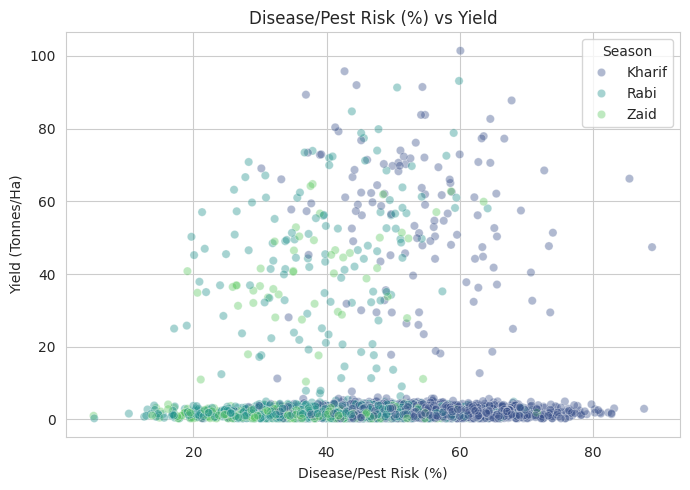

Correlation (Disease/Pest Risk % vs Yield): 0.014


In [ ]:
# Does higher disease/pest risk actually translate into lower yield?
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x='Disease_Pest_Risk_pct', y='Yield_Tonnes_Ha', hue='Season', alpha=0.4, palette='viridis')
plt.title('Disease/Pest Risk (%) vs Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.show()

print("Correlation (Disease/Pest Risk % vs Yield):", round(df['Disease_Pest_Risk_pct'].corr(df['Yield_Tonnes_Ha']), 3))


**Finding:** There is essentially no linear relationship (r ≈ 0.01) between the recorded disease/pest risk score and actual yield. This is a somewhat unexpected pattern — it suggests either that farms are managing pest/disease risk effectively before it affects yield, or that other factors (irrigation, crop choice, season) dominate yield outcomes far more than pest/disease pressure in this dataset.


## 16. Key Insights

1. **Kharif is the strongest season overall** — highest average yield (5.64 t/ha) and the only season with a clearly positive average profit (₹1.79 lakh/farm).
2. **Zaid is the weakest and riskiest season** — lowest average yield (4.67 t/ha), a *negative* average profit (-₹24.8k/farm), and the highest average temperature combined with the lowest average rainfall.
3. **Loss-making farms increase sharply from Kharif to Zaid** — 42.2% of Kharif farms operate at a loss, rising to 51.1% in Rabi and 64.5% in Zaid.
4. **Water-use efficiency, not rainfall, is the strongest driver of yield** — `Water_Efficiency_t_per_1000m3` correlates with yield at r ≈ 0.92, far stronger than rainfall, temperature, or any fertilizer/nutrient input.
5. **Yield and profit are both right-skewed with meaningful outliers** — ~7.5% of farms are yield outliers and ~10% are profit outliers, showing that a subset of farms perform far above or below the typical range regardless of season.
6. **Irrigation method matters more than the raw efficiency ratio suggests** — Drip irrigation delivers the highest yield (6.62 t/ha) of any method, while Rainfed's high efficiency ratio is an artifact of low water usage rather than high productivity, and Flood (the most-used method) is the least water-efficient.
7. **Crop choice is a major profitability driver, independent of season** — Sugarcane and Chilli are profitable in every season, while Wheat, Rice and Maize show average losses overall.
8. **The Zaid slump is broad-based across states**, not isolated to a few regions — every state's lowest seasonal profit occurs in Zaid, with Punjab the only state remaining profitable in all three seasons.
9. **Disease/pest risk shows no meaningful linear relationship with yield** (r ≈ 0.01) in this dataset, suggesting yield outcomes are driven far more by irrigation, crop and seasonal factors than by pest/disease pressure alone.
10. **Profit is driven more by revenue and production volume than by yield per hectare alone** — `Profit_INR` correlates most strongly with `Revenue_INR` (r ≈ 0.89) and `Production_Tonnes` (r ≈ 0.55), reflecting the role of market price and total output alongside per-hectare yield.


## 17. Evidence-Based Recommendations

- **Prioritize Drip irrigation where feasible**, especially for Zaid-season cultivation, since it delivers the highest yield of any irrigation method across all three seasons.
- **Treat Zaid-season cultivation with additional planning support** (credit buffers, drought-tolerant crop varieties, adjusted sowing schedules) given its consistently negative average profit and high loss rate.
- **Encourage diversification toward consistently profitable crops** such as Sugarcane and Chilli where local growing conditions and market access permit, while providing targeted support (input subsidies, price guarantees) for staple crops like Wheat, Rice and Maize that show average losses.
- **Focus resource-efficiency programs on water-use efficiency rather than raw water availability**, since efficiency of use is far more strongly linked to yield than total rainfall or water applied.
- **Investigate the disease/pest risk metric further** before using it as a planning input, since it shows no measurable relationship with yield in this dataset — current pest management practices may already be effective, or the metric may need refinement.
- **Study Punjab's Zaid-season practices as a potential model**, since it is the only state that remains profitable in Zaid while every other state records losses.


## 18. Limitations

- The dataset is **cross-sectional** (one row per farm-season combination) rather than a multi-year time series, so year-to-year trends and the effect of unusual weather years cannot be assessed.
- **Correlation does not imply causation** — for example, the strong link between water efficiency and yield does not by itself prove that improving efficiency *causes* higher yield; unobserved factors (soil quality, farmer experience) may influence both.
- Missing values in `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` were imputed using the median, which is a reasonable approximation but still introduces some artificial values into the dataset.
- Outliers in `Yield_Tonnes_Ha` and `Profit_INR` were retained for analysis; while this preserves genuine extremes, it also means seasonal averages can be pulled in either direction by a small number of unusual farms.
- The dataset covers only 8 states and 8 crops, so findings may not generalize to regions, crops or irrigation practices outside this sample.
- `Disease_Pest_Risk_pct` is a single aggregated score; without knowing exactly how it was measured, it is difficult to fully explain its lack of correlation with yield.


## 19. Final Conclusion

This analysis set out to investigate how agricultural performance varies across seasons, and the evidence points to a clear and consistent pattern: **Kharif is the most productive and profitable season, Rabi is intermediate, and Zaid is consistently the weakest season across nearly every state and metric examined** — lower yield, negative average profit, and the highest share of loss-making farms.

Beyond the season itself, the deeper drivers of performance are **water-use efficiency, irrigation method and crop choice** — factors that farmers and policymakers can influence — rather than raw rainfall or disease/pest risk, which showed weak or negligible relationships with yield in this dataset. These findings support targeted, evidence-based interventions (irrigation upgrades, crop diversification and Zaid-specific planning support) rather than one-size-fits-all agricultural policy across all three seasons.
